# Кросс-секционный блендер: ML учит веса альф вместо равновзвешенности

**Задача:** на каждом баре, по каждому активу — предсказать его **относительную**
доходность следующего бара (демьюненную по срезу: «кто лучше рынка»). Фичи —
сигналы топ-10 семейств альф по этому активу + его собственные характеристики.
Предсказание модели — это просто ещё одна альфа-панель, и деньги ей считает
**тот же fast_sim** (vol-таргетинг, полоса бездействия, комиссии, funding).

**Почему у этой версии есть шанс, в отличие от таймера и меты:**
выборка = бары × активы ≈ 100k+ примеров, а не 1200. Блендер не пытается угадать
«когда» — он учит, *чьему сигналу где верить*.

**Протокол честности:**
1. Топ-10 **семейств** по fitness (дедуп 0.80), TEST в отборе не участвует.
2. **Walk-forward**: расширяющееся окно, рефит каждые 63 бара, эмбарго 5 баров —
   модель предсказывает только бары, которых не видела. TEST внутри walk-forward —
   но это уже 3-й взгляд серии на этот отрезок, держим дисконт.
3. Бейзлайн — **равновзвешенный бленд тех же сигналов через тот же симулятор**
   (одна книга против одной книги; яблоки к яблокам). Плюс топ-1 альфа.
4. Метрики: rank-IC (Spearman по срезу) с t-статистикой И чистый Sharpe после
   костов. IC без денег — не результат.
5. Бустинг — среднее по 3 сидам.

In [1]:
import os, sys, json, warnings, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

warnings.filterwarnings('ignore'); np.seterr(all='ignore')
PROJ = os.getcwd()
S = json.load(open(os.path.join(PROJ, 'alphanode', 'gui_settings.json')))
TF = S.get('timeframe', '1d')
os.environ['ALPHANODE_TF'] = TF
sys.path[:0] = [os.path.join(PROJ, 'evolution'), PROJ]
from config import load_config
from evaluator import build_panel, make_market, eval_alpha_panel
from fastsim import fast_sim
from genome import parse

cfg = load_config()
ANN, FREQ = float(cfg.get('ann', 365.0)), cfg.get('freq', 'D')
VOL, EXEC = float(S['target_vol']), float(S['exec_cost'])
DATA = os.path.join(PROJ, 'data.pickle' if TF == '1d' else f'data_{TF}.pickle')
LIB = os.path.join(PROJ, 'alphanode', 'state',
                   'library.jsonl' if TF == '1d' else f'library_{TF}.jsonl')
TR, VA, TE, EN = (pd.Timestamp(S[k], tz='UTC') for k in
                  ('train_start', 'val_start', 'test_start', 'test_end'))
N_ALPHAS, WF_START, WF_STEP, EMBARGO, HGB_SEEDS = 10, 750, 63, 5, 3
print(f'tf={TF} ann={ANN:g} vol={VOL} exec={EXEC} · WF start {WF_START}, step {WF_STEP}')

tf=1d ann=365 vol=0.36 exec=0.0005 · WF start 750, step 63


## 1. Топ-10 семейств, альфа-панели, фичи активов, таргет

In [2]:
rows = [json.loads(l) for l in open(LIB, encoding='utf-8')]
rows = [r for r in rows if r.get('formula') and isinstance(r.get('base'), (int, float))]
rows.sort(key=lambda c: c['base'], reverse=True)
picked = []
for c in rows:
    if all(difflib.SequenceMatcher(None, c['formula'], p['formula']).ratio() < 0.80
           for p in picked):
        picked.append(c)
    if len(picked) == N_ALPHAS:
        break
print(f'{len(picked)} distinct families (asked for {N_ALPHAS})')

tk, raw, panel = build_panel(DATA, TR.tz_localize(None).to_pydatetime(),
                             EN.tz_localize(None).to_pydatetime(), None, freq=FREQ)
market = make_market(panel, tk, raw, vol_window=cfg.get('vol_window', 30))
idx = panel['ret'].index
elig = market['base_elig']                              # [T, N] tradeable mask
T, N = elig.shape
K = len(picked)

def cs_z(M, e):
    # cross-sectional z-score over the eligible slice of each bar
    X = np.where(e & np.isfinite(M), M, np.nan)
    mu = np.nanmean(X, axis=1, keepdims=True)
    sd = np.nanstd(X, axis=1, keepdims=True)
    return np.where(np.isfinite(X), (X - mu) / np.where(sd < 1e-12, 1.0, sd), 0.0)

AZ = np.zeros((T, N, K))
for k, c in enumerate(picked):
    A = pd.DataFrame(eval_alpha_panel(parse(c['formula']), panel)[tk]
                     .to_numpy(dtype=np.float64)).ffill().to_numpy()
    AZ[:, :, k] = cs_z(A, elig)
ew_signal = AZ.mean(axis=2)                             # the no-ML combiner: mean z-signal

rets = panel['ret'][tk].to_numpy(dtype=np.float64)
close = panel['close'][tk].to_numpy(dtype=np.float64)
mom21 = pd.DataFrame(rets).rolling(21).sum().to_numpy()
mom63 = pd.DataFrame(rets).rolling(63).sum().to_numpy()
vol21 = pd.DataFrame(rets).rolling(21).std().to_numpy() * np.sqrt(ANN)
hi21 = pd.DataFrame(close).rolling(21).max().to_numpy()
dist_hi = np.where(hi21 > 0, close / hi21 - 1.0, 0.0)
fund = (panel['funding'][tk].to_numpy(dtype=np.float64)
        if 'funding' in panel else np.zeros((T, N)))
fund7 = pd.DataFrame(fund).rolling(7).mean().to_numpy()
agree = np.abs(np.sign(AZ).sum(axis=2)) / K             # how unanimous the 10 alphas are

ASSET = np.stack([cs_z(mom21, elig), cs_z(mom63, elig), cs_z(vol21, elig),
                  cs_z(dist_hi, elig), cs_z(fund7, elig), agree], axis=2)
FEATS = np.concatenate([AZ, ASSET], axis=2)             # [T, N, K+6]
FNAMES = [f'alpha{k}' for k in range(K)] + ['mom21', 'mom63', 'vol21',
                                            'dist_hi', 'fund7', 'agree']
r_next = np.vstack([rets[1:], np.full((1, N), np.nan)])
mu_next = np.where(elig, r_next, np.nan)
Y = mu_next - np.nanmean(mu_next, axis=1, keepdims=True)   # demeaned next-bar return
ok = elig & np.isfinite(Y) & np.isfinite(FEATS).all(axis=2)
print(f'features {FEATS.shape[2]} · samples usable: {ok.sum():,} of {T * N:,}')

10 distinct families (asked for 10)


features 16 · samples usable: 21,863 of 24,960


## 2. Walk-forward: Ridge + бустинг (3 сида) + ансамбль

In [3]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

def flat(t0, t1):
    # flatten bars [t0, t1) into a (samples, features) table
    m = ok[t0:t1]
    return FEATS[t0:t1][m], Y[t0:t1][m]

PRED = np.zeros((T, N))                                 # 0 = flat book (pre-OOS and ineligible)
chunk_log = []
for start in range(WF_START, T - 1, WF_STEP):
    Xtr, ytr = flat(0, max(0, start - EMBARGO))
    if len(ytr) < 5000:
        continue
    sc = StandardScaler().fit(Xtr)
    ridge = Ridge(alpha=10.0).fit(sc.transform(Xtr), ytr)
    hgbs = [HistGradientBoostingRegressor(max_depth=3, max_leaf_nodes=15,
                                          learning_rate=0.05, max_iter=300,
                                          l2_regularization=1.0, random_state=s)
            .fit(Xtr, ytr) for s in range(HGB_SEEDS)]
    end = min(start + WF_STEP, T)
    for t in range(start, end):
        m = ok[t]
        if not m.any():
            continue
        Xt = FEATS[t][m]
        pr = (ridge.predict(sc.transform(Xt))
              + np.mean([h.predict(Xt) for h in hgbs], axis=0)) / 2
        PRED[t, m] = pr
    chunk_log.append({'t0': start, 't1': end})
oos_from = chunk_log[0]['t0']
m_oos_bar = np.zeros(T, dtype=bool)
m_oos_bar[oos_from:] = True
print(f'{len(chunk_log)} refits · OOS bars {m_oos_bar.sum()} '
      f'({idx[oos_from].date()} .. {idx[-1].date()})')

27 refits · OOS bars 1683 (2021-11-26 .. 2026-07-05)


## 3. Rank-IC: есть ли в предсказаниях кросс-секционный сигнал

In [4]:
ics = []
for t in range(oos_from, T - 1):
    m = ok[t] & (PRED[t] != 0)
    if m.sum() >= 8:
        ic = spearmanr(PRED[t, m], Y[t, m]).statistic
        if np.isfinite(ic):
            ics.append((t, ic))
ic_t, ic_v = np.array([a for a, _ in ics]), np.array([b for _, b in ics])
tstat = ic_v.mean() / (ic_v.std() / np.sqrt(len(ic_v)))
print(f'rank-IC: mean {ic_v.mean():+.4f} · std {ic_v.std():.3f} · '
      f't-stat {tstat:+.1f} · positive bars {(ic_v > 0).mean():.0%} · n={len(ic_v)}')
# per-quarter IC for stability
q = pd.Series(ic_v, index=idx[ic_t]).resample('QE').mean()
print(f'quarterly IC > 0 in {(q > 0).mean():.0%} of quarters')

rank-IC: mean +0.0058 · std 0.366 · t-stat +0.7 · positive bars 50% · n=1682
quarterly IC > 0 in 55% of quarters


## 4. Деньги: блендер против EW-бленда тех же сигналов (один и тот же симулятор)

Обе книги стартуют плоскими в один день (до OOS сигналы занулены) и проходят через
идентичный fast_sim. Разница между ними — это и есть чистая добавка ML.

In [5]:
def zeroed_pre_oos(sig):
    s = sig.copy()
    s[:oos_from] = 0.0
    return s

books = {'ML blender': zeroed_pre_oos(PRED),
         'EW blend (no ML)': zeroed_pre_oos(ew_signal),
         'top-1 alpha alone': zeroed_pre_oos(AZ[:, :, 0])}
sims = {name: fast_sim(sig, market, VOL, EXEC, ann=ANN,
                       ewma_lambda=cfg.get('ewma_lambda', 0.06))
        for name, sig in books.items()}

m_test_bar = np.asarray(idx >= TE) & m_oos_bar

def metrics(r, mask):
    r = r.values[mask]
    if (r != 0).sum() < 5 or r.std() < 1e-12:
        return dict(sharpe=np.nan, cagr=np.nan, dd=np.nan)
    eq = np.cumprod(1 + r); yrs = len(r) / ANN
    return dict(sharpe=r.mean() * ANN / (r.std() * np.sqrt(ANN)),
                cagr=eq[-1] ** (1 / yrs) - 1 if eq[-1] > 0 else np.nan,
                dd=(eq / np.maximum.accumulate(eq) - 1).min())

out = []
for name, r in sims.items():
    row = {'strategy': name}
    for seg_name, mask in [('WF-OOS', m_oos_bar), ('WF-OOS ∩ TEST', m_test_bar)]:
        m = metrics(r, mask)
        row[f'{seg_name} sharpe'] = round(m['sharpe'], 2)
        row[f'{seg_name} cagr'] = f"{m['cagr']:.0%}" if np.isfinite(m['cagr']) else '—'
        row[f'{seg_name} dd'] = f"{m['dd']:.0%}" if np.isfinite(m['dd']) else '—'
    out.append(row)
pd.DataFrame(out)

,strategy,WF-OOS sharpe,WF-OOS cagr,WF-OOS dd,WF-OOS ∩ TEST sharpe,WF-OOS ∩ TEST cagr,WF-OOS ∩ TEST dd
0,ML blender,0.99,39%,-37%,1.27,59%,-37%
1,EW blend (no ML),1.87,96%,-55%,1.57,78%,-55%
2,top-1 alpha alone,1.33,58%,-61%,1.08,44%,-61%


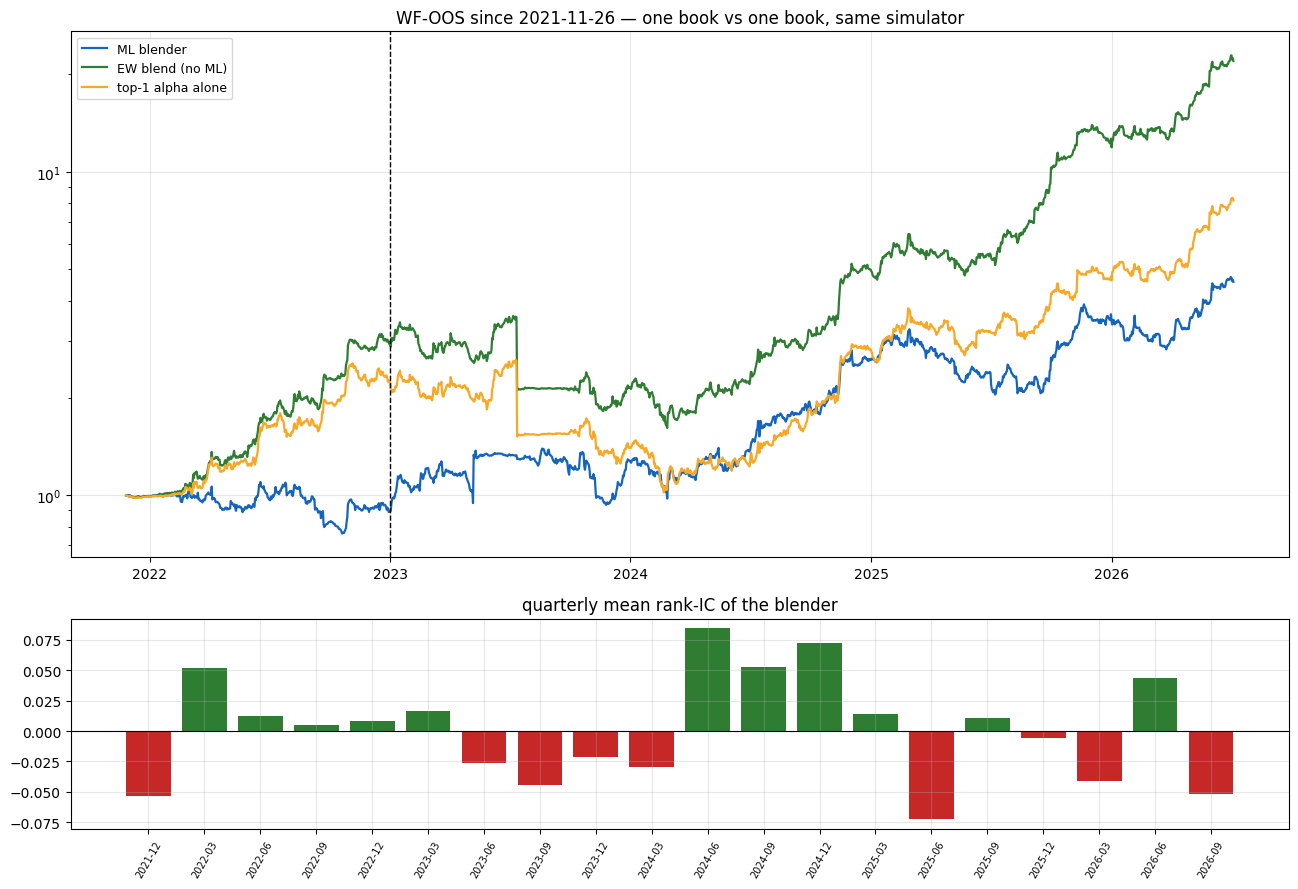

In [6]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                              gridspec_kw={'height_ratios': [3, 1.2]})
for (name, r), col in zip(sims.items(), ('#1565c0', '#2e7d32', '#f9a825')):
    rr = r.iloc[oos_from:]
    ax.plot(rr.index, (1 + rr).cumprod(), lw=1.6, color=col, label=name)
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
ax.axvline(TE, color='k', ls='--', lw=1)
ax.set_title(f'WF-OOS since {idx[oos_from].date()} — one book vs one book, same simulator')
qq = pd.Series(ic_v, index=idx[ic_t]).resample('QE').mean()
ax2.bar(range(len(qq)), qq.values,
        color=['#2e7d32' if v > 0 else '#c62828' for v in qq.values])
ax2.set_xticks(range(len(qq)))
ax2.set_xticklabels([d.strftime('%Y-%m') for d in qq.index], rotation=60, fontsize=7)
ax2.axhline(0, color='k', lw=0.8); ax2.grid(alpha=0.3)
ax2.set_title('quarterly mean rank-IC of the blender')
plt.tight_layout(); plt.show()

In [7]:
# which features the LAST refit actually used
Xtr, ytr = flat(0, T - WF_STEP)
sc = StandardScaler().fit(Xtr)
ridge = Ridge(alpha=10.0).fit(sc.transform(Xtr), ytr)
hgb = HistGradientBoostingRegressor(max_depth=3, max_leaf_nodes=15, learning_rate=0.05,
                                    max_iter=300, l2_regularization=1.0,
                                    random_state=0).fit(Xtr, ytr)
imp = pd.DataFrame({'feature': FNAMES,
                    'ridge coef (std)': np.round(ridge.coef_, 5)})
imp['|coef|'] = imp['ridge coef (std)'].abs()
imp.sort_values('|coef|', ascending=False).drop(columns='|coef|').head(16)

,feature,ridge coef (std)
6,alpha6,0.00137
2,alpha2,0.00104
7,alpha7,0.00101
13,dist_hi,-0.00091
11,mom63,0.00085
8,alpha8,-0.00068
5,alpha5,0.00068
3,alpha3,0.00053
15,agree,0.00052
14,fund7,-0.00050


## 5. Как читать

- **Сигнал**: rank-IC с |t-stat| ≥ 3 и положительный в большинстве кварталов —
  реальный; t-stat < 2 — шум, каким бы ни был Sharpe.
- **Деньги**: единственная пара, которая имеет значение — «ML blender» против
  «EW blend (no ML)». Обе книги идентичны по механике; разница — вклад модели.
  Топ-1 альфа показывает, не проще ли вообще не смешивать.
- **Коэффициенты Ridge**: если почти весь вес на 1–2 альфах — блендер выродился
  в «выбери лучшую in-sample», это опасный режим (селекция, а не смешивание).
  Если веса распределены и фичи активов ненулевые — модель делает что-то умнее.
- Помни: TEST-отрезок в этой серии смотрится уже третий раз. Окончательный судья —
  форвард-трек: заэнроллить блендер как стратегию и дать ему жить на живых барах.